In [1]:
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 26.0 MB/s eta 0:00:0000:01


In [2]:
import os
import yaml
from ultralytics import YOLO
import torch

print("CUDA available:", torch.cuda.is_available())
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
CUDA available: True
Device: cuda


In [3]:
DATASET_ROOT = "/kaggle/input/datasets/georgelukaanya/yolov11-hospital-model"

print("Files in dataset root:")
print(os.listdir(DATASET_ROOT))

Files in dataset root:
['README.dataset.txt', 'README.roboflow.txt', 'data.yaml', 'valid', 'test', 'train']


In [4]:
DATA_YAML = os.path.join(DATASET_ROOT, "data.yaml")

with open(DATA_YAML, "r") as f:
    data_config = yaml.safe_load(f)

print(data_config)

{'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 8, 'names': ['Monitor', 'Saline Stand', 'bed', 'bin', 'chair', 'sofa', 'stool', 'tools_table'], 'roboflow': {'workspace': 'ademnea2', 'project': 'hospital-314ru-qa1pl', 'version': 2, 'license': 'Private', 'url': 'https://universe.roboflow.com/ademnea2/hospital-314ru-qa1pl/dataset/2'}}


In [5]:
fixed_data_config = data_config.copy()

fixed_data_config["path"] = DATASET_ROOT
fixed_data_config["train"] = os.path.join(DATASET_ROOT, "train", "images")
fixed_data_config["val"]   = os.path.join(DATASET_ROOT, "valid", "images")
fixed_data_config["test"]  = os.path.join(DATASET_ROOT, "test", "images")

FIXED_YAML = "/kaggle/working/data_fixed.yaml"

with open(FIXED_YAML, "w") as f:
    yaml.dump(fixed_data_config, f)

print("Fixed YAML saved to:", FIXED_YAML)
print(fixed_data_config)

Fixed YAML saved to: /kaggle/working/data_fixed.yaml
{'train': '/kaggle/input/datasets/georgelukaanya/yolov11-hospital-model/train/images', 'val': '/kaggle/input/datasets/georgelukaanya/yolov11-hospital-model/valid/images', 'test': '/kaggle/input/datasets/georgelukaanya/yolov11-hospital-model/test/images', 'nc': 8, 'names': ['Monitor', 'Saline Stand', 'bed', 'bin', 'chair', 'sofa', 'stool', 'tools_table'], 'roboflow': {'workspace': 'ademnea2', 'project': 'hospital-314ru-qa1pl', 'version': 2, 'license': 'Private', 'url': 'https://universe.roboflow.com/ademnea2/hospital-314ru-qa1pl/dataset/2'}, 'path': '/kaggle/input/datasets/georgelukaanya/yolov11-hospital-model'}


In [6]:
model = YOLO("yolo11s.pt")

In [9]:
results = model.train(
    data=FIXED_YAML,
    epochs=50,
    imgsz=1024,
    batch=8,
    device=0 if torch.cuda.is_available() else "cpu",

    # augmentations / robustness
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    translate=0.1,
    scale=0.2,
    fliplr=0.5,
    mosaic=1.0,
    mixup=0.0,

    # optimization
    optimizer="SGD",
    lr0=0.005,
    momentum=0.9,
    weight_decay=0.0005,

    # training behavior
    patience=20,
    workers=2,
    cache=False,

    project="/kaggle/working",
    name="yolo11_hospital"
)

Ultralytics 8.4.22 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data_fixed.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.9, mosaic=1.0, multi_scale=0.0, name=yolo11_hospital2, nbs=64, nms=False, opset=None, optimize=False, optimizer=SGD, overlap_mask=True, patien

In [13]:
best_model_path = "/kaggle/working/yolo11_hospital2/weights/best.pt"

best_model = YOLO(best_model_path)

val_results = best_model.val(data=FIXED_YAML)
print(val_results)

Ultralytics 8.4.22 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
YOLO11s summary (fused): 101 layers, 9,415,896 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 3.9±3.3 ms, read: 111.6±60.3 MB/s, size: 64.8 KB)
val: Scanning /kaggle/input/datasets/georgelukaanya/yolov11-hospital-model/valid/labels... 272 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 272/272 527.4it/s 0.5s0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/georgelukaanya/yolov11-hospital-model/valid is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 17/17 2.5it/s 6.8s0.3s
                   all        272        416      0.802      0.791      0.813      0.639
               Monitor         80        102      0.854      0.746      0.836      0.547
          Saline Stand         29         41      0.867      0.829      0.862       0.74
                   bed         71  

In [14]:
metrics = {
    "precision": float(val_results.box.mp),
    "recall": float(val_results.box.mr),
    "mAP50": float(val_results.box.map50),
    "mAP50_95": float(val_results.box.map)
}

print(metrics)

{'precision': 0.8022708615987555, 'recall': 0.7905921185555211, 'mAP50': 0.8125227243725777, 'mAP50_95': 0.6392368007756508}


In [15]:
names = best_model.names

per_class_rows = []
for i, cls_name in names.items():
    per_class_rows.append({
        "class_id": i,
        "class_name": cls_name,
        "ap50": float(val_results.box.ap50[i]) if i < len(val_results.box.ap50) else None,
        "ap50_95": float(val_results.box.ap[i]) if i < len(val_results.box.ap) else None
    })

import pandas as pd
per_class_df = pd.DataFrame(per_class_rows)
per_class_df

,class_id,class_name,ap50,ap50_95
0,0,Monitor,0.835964,0.547254
1,1,Saline Stand,0.862334,0.740483
2,2,bed,0.914364,0.762783
3,3,bin,0.372500,0.231388
4,4,chair,0.877481,0.678185
5,5,sofa,0.963952,0.837740
6,6,stool,0.905417,0.801664
7,7,tools_table,0.768169,0.514398


In [16]:
VAL_IMAGES_DIR = os.path.join(DATASET_ROOT, "valid", "images")

sample_images = sorted([
    os.path.join(VAL_IMAGES_DIR, f)
    for f in os.listdir(VAL_IMAGES_DIR)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
])[:5]

pred_results = best_model.predict(
    source=sample_images,
    conf=0.5,
    save=True,
    project="/kaggle/working",
    name="yolo11_predictions"
)


0: 1024x1024 1 chair, 13.5ms
1: 1024x1024 1 Saline Stand, 13.5ms
2: 1024x1024 1 Saline Stand, 13.5ms
3: 1024x1024 1 stool, 13.5ms
4: 1024x1024 1 chair, 13.5ms
Speed: 5.1ms preprocess, 13.5ms inference, 0.9ms postprocess per image at shape (1, 3, 1024, 1024)
Results saved to /kaggle/working/yolo11_predictions


['/kaggle/working/yolo11_predictions/image0.jpg', '/kaggle/working/yolo11_predictions/image1.jpg', '/kaggle/working/yolo11_predictions/image2.jpg']


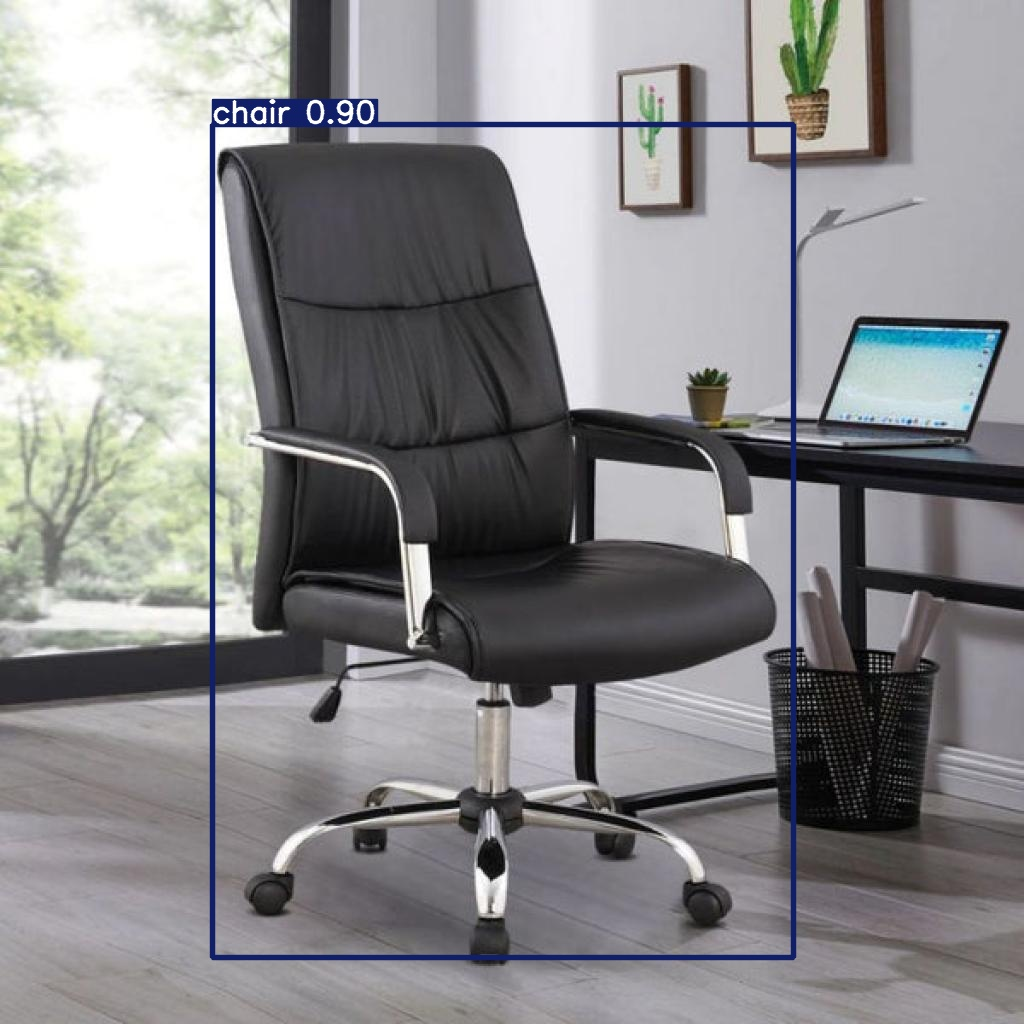

In [17]:
from IPython.display import Image as IPyImage, display

pred_dir = "/kaggle/working/yolo11_predictions"
pred_files = sorted([
    os.path.join(pred_dir, f)
    for f in os.listdir(pred_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
])

print(pred_files[:3])

if pred_files:
    display(IPyImage(filename=pred_files[0]))

In [18]:
import time

test_images = sample_images[:3]

start = time.time()
_ = best_model.predict(source=test_images, conf=0.5, verbose=False)
end = time.time()

avg_time = (end - start) / len(test_images)
fps = 1.0 / avg_time if avg_time > 0 else 0.0

print("Average inference time per image (sec):", avg_time)
print("Estimated FPS:", fps)

Average inference time per image (sec): 0.03894209861755371
Estimated FPS: 25.67915021275293


In [19]:
import json

output_metrics_path = "/kaggle/working/yolo11_metrics.json"
per_class_csv_path = "/kaggle/working/yolo11_per_class_metrics.csv"

with open(output_metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)

per_class_df.to_csv(per_class_csv_path, index=False)

print("Saved:")
print(output_metrics_path)
print(per_class_csv_path)
print(best_model_path)

Saved:
/kaggle/working/yolo11_metrics.json
/kaggle/working/yolo11_per_class_metrics.csv
/kaggle/working/yolo11_hospital2/weights/best.pt
